# Kidney Disease Dataset - Machine Learning Pipeline
This notebook handles preprocessing, model training, evaluation, and saves the best model pipeline for production deployment.

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report


## 1. Data Validation & Loading

In [9]:
DATA_PATH = '../datasets/kidney/kidney_disease_dataset.csv'

print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")

TARGET = 'Target'

# Verify target exists
assert TARGET in df.columns, f"Target column '{TARGET}' not found in the dataset!"

# Basic Data Validation
print(f"Total Missing Values: {df.isnull().sum().sum()}")
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows. Dropping duplicates...")
    df = df.drop_duplicates()
    print(f"New dataset shape: {df.shape}")

# Ensure target is binary encoded (0 and 1) for modeling
le = LabelEncoder()
df[TARGET] = le.fit_transform(df[TARGET])
print(f"Target mapped classes: {le.classes_} -> {le.transform(le.classes_)}")

df.head()


Loading dataset from: ../datasets/kidney/kidney_disease_dataset.csv
Dataset shape: (20538, 43)
Total Missing Values: 0
Target mapped classes: ['High_Risk' 'Low_Risk' 'Moderate_Risk' 'No_Disease' 'Severe_Disease'] -> [0 1 2 3 4]


,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,3
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,1
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,3
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,3
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,3


## 2. Train-Test Split & Features Identification

In [10]:
# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Automatically identify categorical and numerical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Sometimes binary numerical flags act as categories, but StandardScaler handles them fine.
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


Train set: (16430, 42), Test set: (4108, 42)
Numerical features (28): ['Age of the patient', 'Blood pressure (mm/Hg)', 'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine', 'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)', 'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)', 'Potassium level (mEq/L)', 'Hemoglobin level (gms)', 'Packed cell volume (%)', 'White blood cell count (cells/cumm)', 'Red blood cell count (millions/cumm)', 'Estimated Glomerular Filtration Rate (eGFR)', 'Urine protein-to-creatinine ratio', 'Urine output (ml/day)', 'Serum albumin level', 'Cholesterol level', 'Parathyroid hormone (PTH) level', 'Serum calcium level', 'Serum phosphate level', 'Body Mass Index (BMI)', 'Duration of diabetes mellitus (years)', 'Duration of hypertension (years)', 'Cystatin C level', 'C-reactive protein (CRP) level', 'Interleukin-6 (IL-6) level']
Categorical features (14): ['Red blood cells in urine', 'Pus cells in urine', 'Pus cell clumps in urine', 'Bacteria in uri

C:\Users\hp\AppData\Local\Temp\ipykernel_1060\750364604.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


## 3. Preprocessing Pipeline

In [11]:
# Production-ready Preprocessing
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Fitting preprocessor...")
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
print(f"Transformed train shape: {X_train_preprocessed.shape}")
print("Preprocessing complete!")


Fitting preprocessor...
Transformed train shape: (16430, 57)
Preprocessing complete!


## 4. Model Training

In [12]:
# Initialize models optimized for deployment
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_preprocessed, y_train)
    trained_models[name] = model
print("Training complete!")


Training Logistic Regression...


c:\Users\hp\django\MediSense\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training Random Forest...
Training XGBoost...


c:\Users\hp\django\MediSense\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:19:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete!


## 5. Evaluation & Confusion Matrices

c:\Users\hp\django\MediSense\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\django\MediSense\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\django\MediSense\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


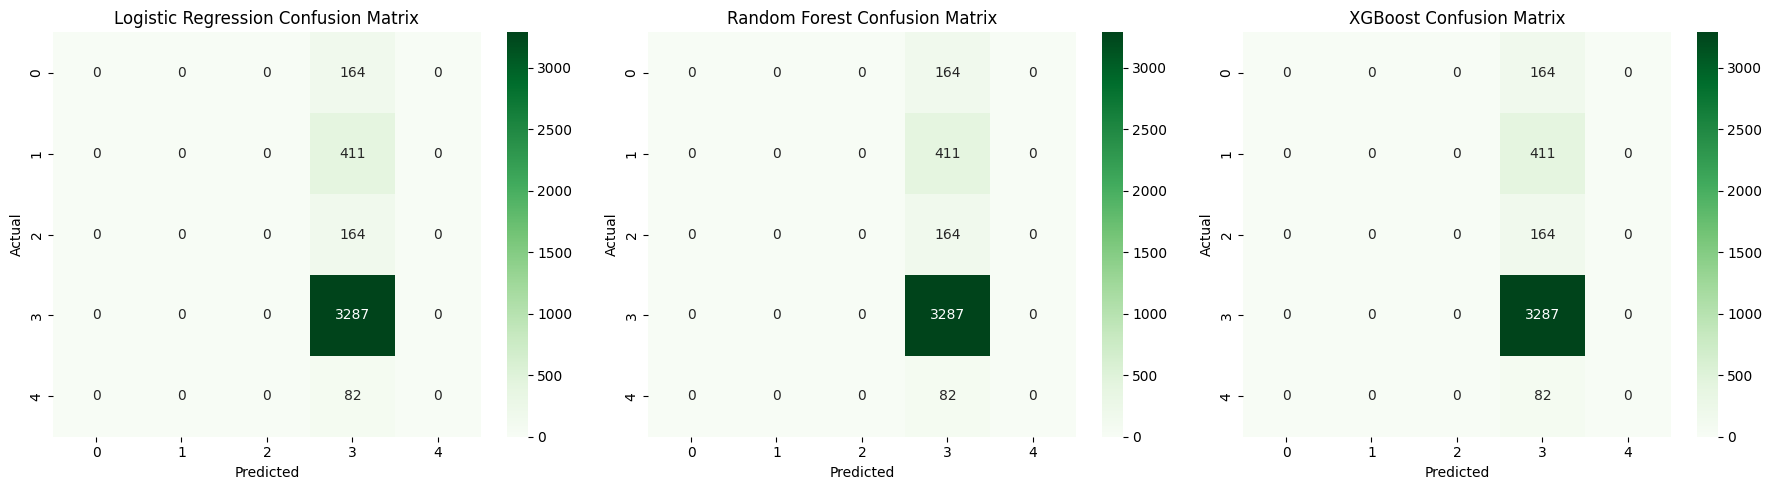

In [13]:
results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_preprocessed)
    y_prob = model.predict_proba(X_test_preprocessed)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 6. Model Comparison & Best Model Selection

In [14]:
# Create comparison report
results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison Report:")
display(results_df)

# Select best model based on ROC AUC
best_model_name = results_df['ROC AUC'].idxmax()
best_model = trained_models[best_model_name]
print(f"\nBest Model selected based on ROC AUC: **{best_model_name}**")


Model Comparison Report:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.800146,0.640234,0.800146,0.711313,0.491896
Random Forest,0.800146,0.640234,0.800146,0.711313,0.511012
XGBoost,0.800146,0.640234,0.800146,0.711313,0.502747



Best Model selected based on ROC AUC: **Random Forest**


## 7. Save Best Model Pipeline

In [15]:
# Bundle preprocessor and best model into a single deployable artifact
os.makedirs('../models', exist_ok=True)
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

model_path = '../models/kidney_model.pkl'
joblib.dump(full_pipeline, model_path)
print(f"Successfully saved complete {best_model_name} pipeline to {model_path}")


Successfully saved complete Random Forest pipeline to ../models/kidney_model.pkl


## 8. Feature Importance Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_1060\754707293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


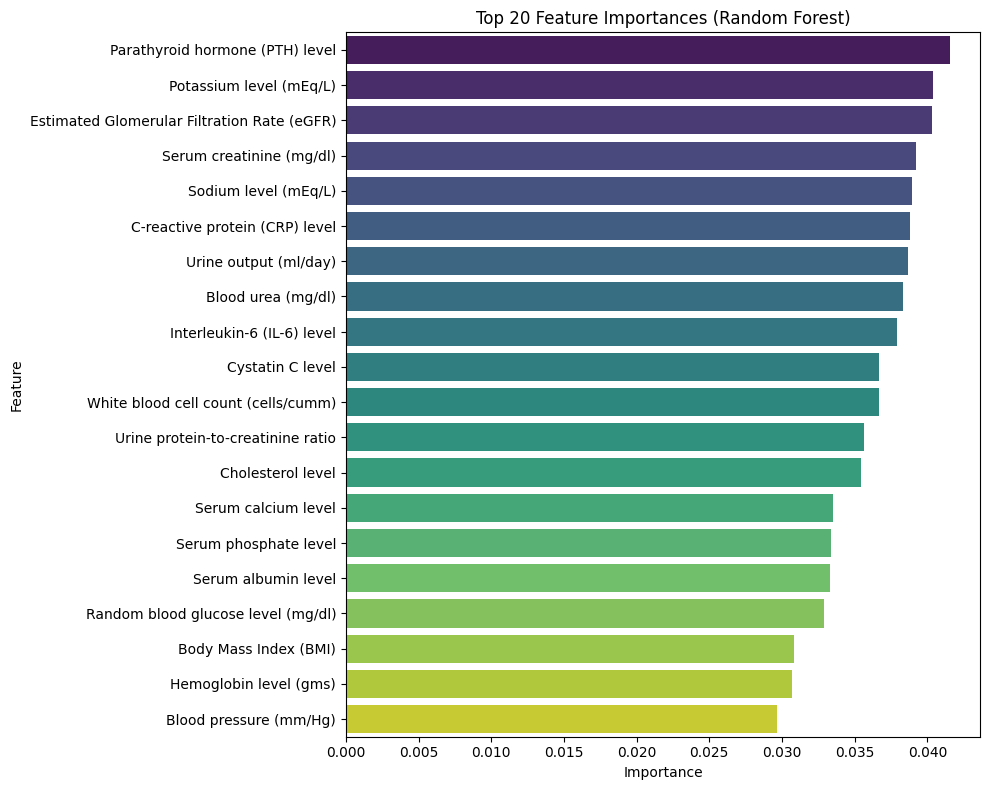

In [16]:
# Extract feature names from OneHotEncoder
cat_features_out = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(cat_features_out)

if best_model_name == 'Logistic Regression':
    importances = np.abs(best_model.coef_).mean(axis=0)
else:
    importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title(f'Top 20 Feature Importances ({best_model_name})')
plt.tight_layout()
plt.show()
